# DATASCI 503, Homework 9: Clustering and Principal Component Analysis

In this assignment, you will practice hierarchical clustering, K-means clustering, and Principal Component Analysis (PCA). You will work with both synthetic dissimilarity matrices and real-world data.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

## Part 1: Hierarchical Clustering with a Dissimilarity Matrix

Consider the following dissimilarity matrix for four observations:

$$D = \begin{bmatrix}
0 & 0.3 & 0.4 & 0.7 \\
0.3 & 0 & 0.5 & 0.8 \\
0.4 & 0.5 & 0 & 0.45 \\
0.7 & 0.8 & 0.45 & 0
\end{bmatrix}$$

The rows and columns correspond to observations 1, 2, 3, and 4 respectively.

---

**Problem 1a (ISLP Ch 12, Exercise 2):** Complete Linkage Dendrogram

Using the dissimilarity matrix above, perform hierarchical clustering with **complete linkage** and plot the dendrogram.

Store the linkage result in a variable called `linkage_complete`.

In [4]:
# linkage?

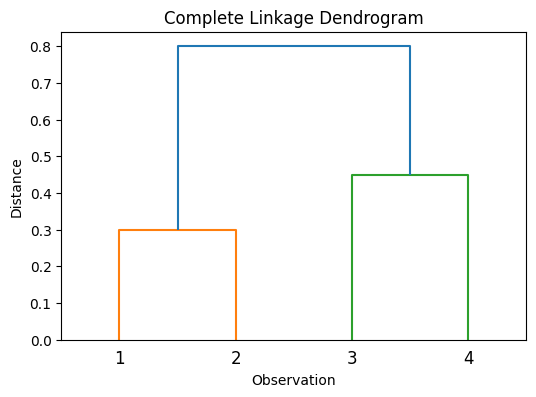

In [ ]:
dissimilarity_matrix = np.array(
    [
        [0, 0.3, 0.4, 0.7],
        [0.3, 0, 0.5, 0.8],
        [0.4, 0.5, 0, 0.45],
        [0.7, 0.8, 0.45, 0],
    ]
)
observation_names = np.array(["1", "2", "3", "4"])

# Complete Linkage; requires condensed distance matrix via squareform
linkage_complete = linkage(squareform(dissimilarity_matrix), method="complete")

plt.figure(figsize=(6, 4))
dendrogram(linkage_complete, labels=observation_names)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [15]:
# Test assertions
assert linkage_complete is not None, "linkage_complete should be defined"
assert linkage_complete.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


Single linkage merges clusters based on the minimum pairwise distance, leading to chaining and earlier merges, while complete linkage uses the maximum pairwise distance, producing tighter clusters and later merges at higher dendrogram heights.

---

**Problem 1b:** Single Linkage Dendrogram

Now perform hierarchical clustering with **single linkage** on the same dissimilarity matrix and plot the dendrogram.

Store the linkage result in a variable called `linkage_single`.

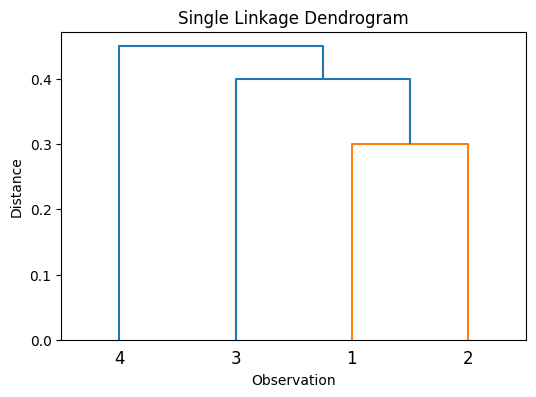

In [7]:
linkage_single = linkage(squareform(dissimilarity_matrix), method="single")

plt.figure(figsize=(6, 4))
dendrogram(linkage_single, labels=observation_names)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [17]:
# Test assertions
assert linkage_single is not None, "linkage_single should be defined"
assert linkage_single.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


---

**Problem 1c:** Cutting the Complete Linkage Dendrogram

Cut the **complete linkage** dendrogram at a height that produces exactly **2 clusters**. Use a distance threshold of `t=0.5`.

Store the cluster assignments in a variable called `clusters_complete`.

Print the cluster memberships showing which observations belong to each cluster.

In [9]:
clusters_complete

array([1, 1, 2, 2], dtype=int32)

In [ ]:
# fcluster flattens the hierarchical clustering into flat clusters based on a distance threshold
clusters_complete = fcluster(linkage_complete, t=0.5, criterion="distance")

for cluster_id in np.unique(clusters_complete):
    members = observation_names[clusters_complete == cluster_id]
    # string join to print members of each cluster
    print(f"Cluster {cluster_id}: {', '.join(members)}")

Cluster 1: 1, 2
Cluster 2: 3, 4


In [19]:
# Test assertions
assert clusters_complete is not None, "clusters_complete should be defined"
assert len(clusters_complete) == 4, "Should have cluster assignments for 4 observations"
assert len(np.unique(clusters_complete)) == 2, "Should produce exactly 2 clusters"
print("All tests passed!")

All tests passed!


---

**Problem 1d:** Cutting the Single Linkage Dendrogram

Cut the **single linkage** dendrogram at a height of `t=0.42` to produce 2 clusters.

Store the cluster assignments in a variable called `clusters_single`.

Print the cluster memberships.

In [11]:
clusters_single = fcluster(linkage_single, t=0.42, criterion="distance")

for cluster_id in np.unique(clusters_single):
    members = observation_names[clusters_single == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members)}")

Cluster 1: 1, 2, 3
Cluster 2: 4


In [21]:
# Test assertions
assert clusters_single is not None, "clusters_single should be defined"
assert len(clusters_single) == 4, "Should have cluster assignments for 4 observations"
print("All tests passed!")

All tests passed!


---

**Problem 1e:** Reordering the Dendrogram

Dendrograms can look different depending on how sibling nodes are ordered, even though they represent the same clustering. Demonstrate this by reordering the observations and showing that the dendrogram looks different but represents the same hierarchical structure.

Swap the order of observations: use the order [2, 1, 4, 3] instead of [1, 2, 3, 4].

Store the new linkage result in `linkage_reordered` and plot the dendrogram.

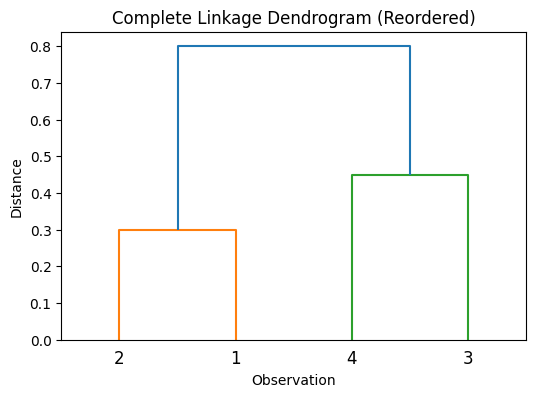

In [14]:
reorder_idx = np.array([1, 0, 3, 2])
reordered_matrix = dissimilarity_matrix[np.ix_(reorder_idx, reorder_idx)]
reordered_names = observation_names[reorder_idx]

linkage_reordered = linkage(squareform(reordered_matrix), method="complete")

plt.figure(figsize=(6, 4))
dendrogram(linkage_reordered, labels=reordered_names)
plt.title("Complete Linkage Dendrogram (Reordered)")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [15]:
# Test assertions
assert linkage_reordered is not None, "linkage_reordered should be defined"
assert linkage_reordered.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


## Part 2: Principal Component Analysis Theory

Consider a dataset with 2 features. The eigenvectors and eigenvalues of the covariance matrix are:

$$U = \begin{bmatrix} u_1 & u_2 \end{bmatrix} = \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix}$$

$$\Lambda = \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} = \begin{bmatrix} 4 & 0 \\ 0 & 1 \end{bmatrix}$$

where $u_1$ and $u_2$ are the principal component directions (columns of $U$) and $\lambda_1, \lambda_2$ are the corresponding eigenvalues (variances).

---

**Problem 2a:** Computing the Covariance Matrix (free response)

Given the eigenvectors $U$ and eigenvalues $\Lambda$, compute the original covariance matrix using the relationship:

$$\Sigma = U \Lambda U^T$$

Show your work and express the final answer as a 2x2 matrix.

Using
$$
U = \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix}, \quad
\Lambda = \begin{bmatrix} 4 & 0 \\ 0 & 1 \end{bmatrix}
$$

First compute
$$
U\Lambda = \begin{bmatrix} 2.4 & -0.8 \\ 3.2 & 0.6 \end{bmatrix}
$$

Then
$$
\Sigma = U\Lambda U^T = \begin{bmatrix} 2.08 & 1.44 \\ 1.44 & 2.92 \end{bmatrix}
$$

---

**Problem 2b:** Variance Explained (free response)

What percentage of the total variance is explained by the first principal component?

Show your calculation.

The first principal component explains
$$
\frac{\lambda_1}{\lambda_1 + \lambda_2} = \frac{4}{4 + 1} = \frac{4}{5} = 0.8
$$

So the first principal component explains **80%** of the total variance.

---

**Problem 2c:** Computing Principal Component Scores (free response)

For a data point $x = [1, 2]$, compute the scores (projections) onto both principal components.

Recall that the score for PC $i$ is computed as $PC_i = x \cdot u_i$.

Show your work.

For $x = [1, 2]$:

$$
PC_1 = x \cdot u_1 = [1, 2] \cdot [0.6, 0.8] = 0.6 + 1.6 = 2.2
$$

$$
PC_2 = x \cdot u_2 = [1, 2] \cdot [-0.8, 0.6] = -0.8 + 1.2 = 0.4
$$

So the scores are **PC1 = 2.2** and **PC2 = 0.4**.

## Part 3: Clustering US Arrests Data

In this question, you will apply clustering techniques to the US Arrests dataset, which contains violent crime rates per 100,000 residents for each US state. The variables are:
- **Murder**: Murder arrests per 100,000
- **Assault**: Assault arrests per 100,000
- **UrbanPop**: Percent urban population
- **Rape**: Rape arrests per 100,000

In [16]:
from statsmodels.datasets import get_rdataset

# Download the USArrests dataset
arrests = get_rdataset("USArrests").data.reset_index().rename(columns={"index": "rownames"})

state_names = arrests["rownames"].values
features = arrests.drop(["rownames"], axis=1)

print(f"Dataset shape: {features.shape}")
print(f"Features: {list(features.columns)}")
features.head()

Dataset shape: (50, 4)
Features: ['Murder', 'Assault', 'UrbanPop', 'Rape']


,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


---

**Problem 3a:** Hierarchical Clustering Dendrogram

Perform hierarchical clustering on the (unscaled) US Arrests data using **complete linkage** and plot the dendrogram.

Store the linkage result in a variable called `arrests_linkage`.

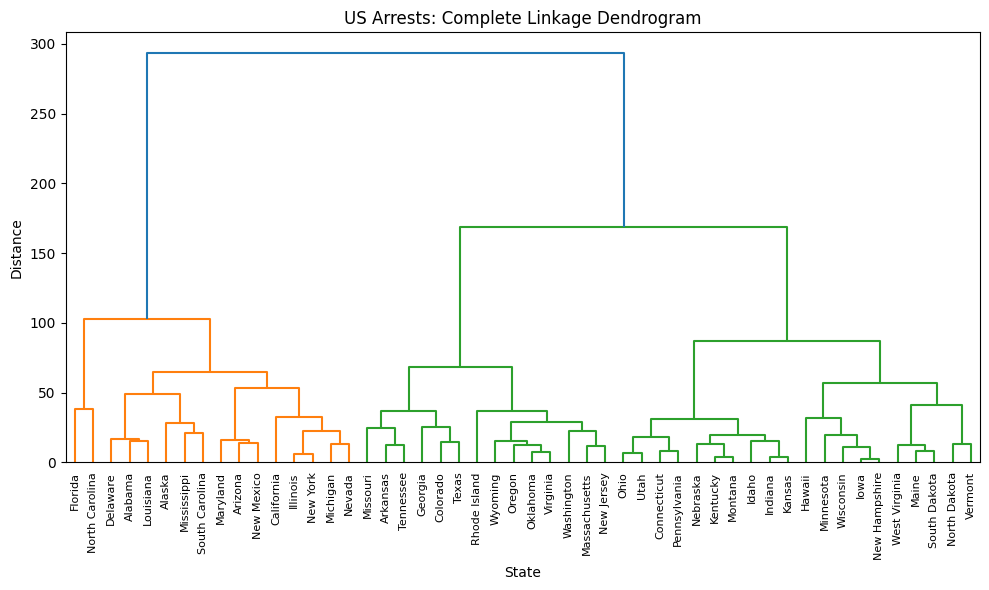

In [20]:
arrests_linkage = linkage(features, method="complete")

plt.figure(figsize=(10, 6))
dendrogram(arrests_linkage, labels=state_names, leaf_rotation=90)
plt.title("US Arrests: Complete Linkage Dendrogram")
plt.xlabel("State")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [27]:
# Test assertions
assert arrests_linkage is not None, "arrests_linkage should be defined"
assert arrests_linkage.shape[0] == 49, "Linkage should have 49 merges (50 states - 1)"
assert arrests_linkage.shape[1] == 4, "Linkage matrix should have 4 columns"
print("All tests passed!")

All tests passed!


---

**Problem 3b:** Cutting into 5 Clusters

Cut the dendrogram at a distance threshold of `t=75` to obtain cluster assignments.

Store the cluster labels in a variable called `hierarchical_labels`.

Print which states belong to each cluster.

In [22]:
hierarchical_labels = fcluster(arrests_linkage, t=75, criterion="distance")

for cluster_id in np.unique(hierarchical_labels):
    states = state_names[hierarchical_labels == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(states)}")

Cluster 1: Florida, North Carolina
Cluster 2: Alabama, Alaska, Arizona, California, Delaware, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, South Carolina
Cluster 3: Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma, Oregon, Rhode Island, Tennessee, Texas, Virginia, Washington, Wyoming
Cluster 4: Connecticut, Idaho, Indiana, Kansas, Kentucky, Montana, Nebraska, Ohio, Pennsylvania, Utah
Cluster 5: Hawaii, Iowa, Maine, Minnesota, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin


In [23]:
# Test assertions
assert hierarchical_labels is not None, "hierarchical_labels should be defined"
assert len(hierarchical_labels) == 50, "Should have labels for 50 states"
num_clusters = len(np.unique(hierarchical_labels))
assert num_clusters == 5, f"Should produce 5 clusters at t=75, got {num_clusters}"
print("All tests passed!")

All tests passed!


Here is a helper function to create silhouette plots for evaluating cluster quality:

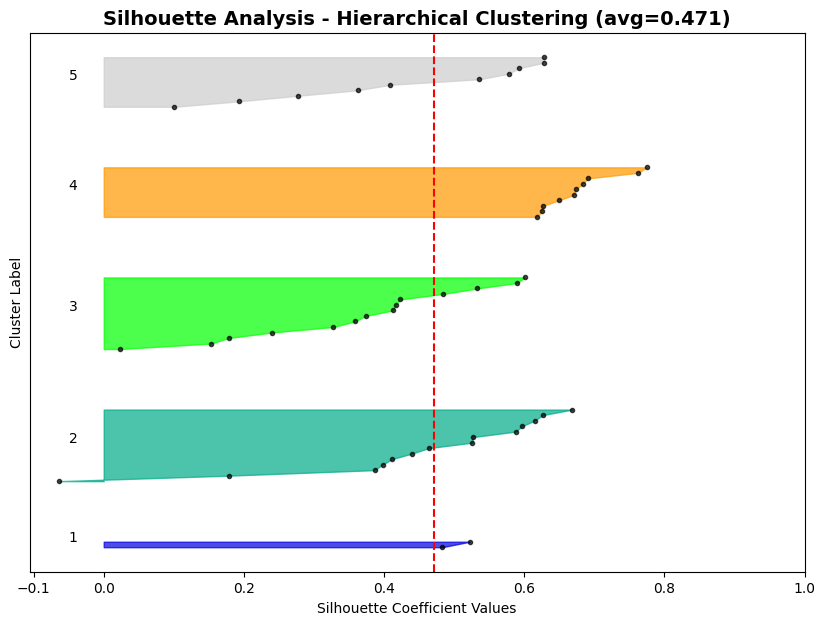

In [24]:
def silhouette_plot(data, labels):
    """Create a silhouette plot and return the average silhouette score."""
    silhouette_avg = silhouette_score(data, labels, metric="euclidean")
    sample_silhouette_values = silhouette_samples(data, labels)
    y_lower = 10

    for cluster_id in np.unique(labels):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()

        cluster_size = cluster_silhouette_values.shape[0]
        y_upper = y_lower + cluster_size

        color = plt.cm.nipy_spectral(float(cluster_id) / 5)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        plt.plot(
            cluster_silhouette_values,
            np.arange(y_lower, y_upper),
            "k.",
            alpha=0.7,
        )
        plt.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id))
        y_lower = y_upper + 10

    plt.xlabel("Silhouette Coefficient Values")
    plt.ylabel("Cluster Label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    return silhouette_avg


# Create silhouette plot for hierarchical clustering
plt.figure(figsize=(10, 7))
silhouette_hierarchical = silhouette_plot(features, hierarchical_labels)
plt.title(
    f"Silhouette Analysis - Hierarchical Clustering (avg={silhouette_hierarchical:.3f})",
    fontsize=14,
    fontweight="bold",
)
plt.show()

The silhouette plot shows moderate clustering quality with an average score of approximately 0.47. Some clusters (e.g., Cluster 4) are well-separated with high silhouette values, while others contain points near zero, indicating overlap or weak assignment. This suggests the chosen number of clusters may not fully capture the underlying structure.

---

**Problem 3c:** K-Means Clustering

Apply K-means clustering to the (unscaled) US Arrests data with `n_clusters=5` and `random_state=33`.

Store the fitted KMeans object in a variable called `kmeans_model` and the cluster labels (1-indexed) in `kmeans_labels`.

Print which states belong to each cluster and compare the silhouette score with hierarchical clustering.

In [25]:
kmeans_model = KMeans(n_clusters=5, random_state=33).fit(features)
kmeans_labels = kmeans_model.labels_ + 1

for cluster_id in np.unique(kmeans_labels):
    states = state_names[kmeans_labels == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(states)}")

silhouette_kmeans = silhouette_score(features, kmeans_labels)
print(f"Silhouette score - Hierarchical: {silhouette_hierarchical:.4f}")
print(f"Silhouette score - K-Means:      {silhouette_kmeans:.4f}")

Cluster 1: Alabama, Alaska, California, Delaware, Illinois, Louisiana, Michigan, Mississippi, Nevada, New Mexico, New York, South Carolina
Cluster 2: Connecticut, Idaho, Indiana, Kansas, Kentucky, Montana, Nebraska, Ohio, Pennsylvania, Utah
Cluster 3: Arizona, Florida, Maryland, North Carolina
Cluster 4: Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma, Oregon, Rhode Island, Tennessee, Texas, Virginia, Washington, Wyoming
Cluster 5: Hawaii, Iowa, Maine, Minnesota, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
Silhouette score - Hierarchical: 0.4713
Silhouette score - K-Means:      0.4493


c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Bryant Willoughby\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bryant Willoughby\AppData\Local\Program

In [26]:
# Test assertions
assert kmeans_model is not None, "kmeans_model should be defined"
assert kmeans_labels is not None, "kmeans_labels should be defined"
assert len(kmeans_labels) == 50, "Should have labels for 50 states"
assert len(np.unique(kmeans_labels)) == 5, "Should have exactly 5 clusters"
print("All tests passed!")

All tests passed!


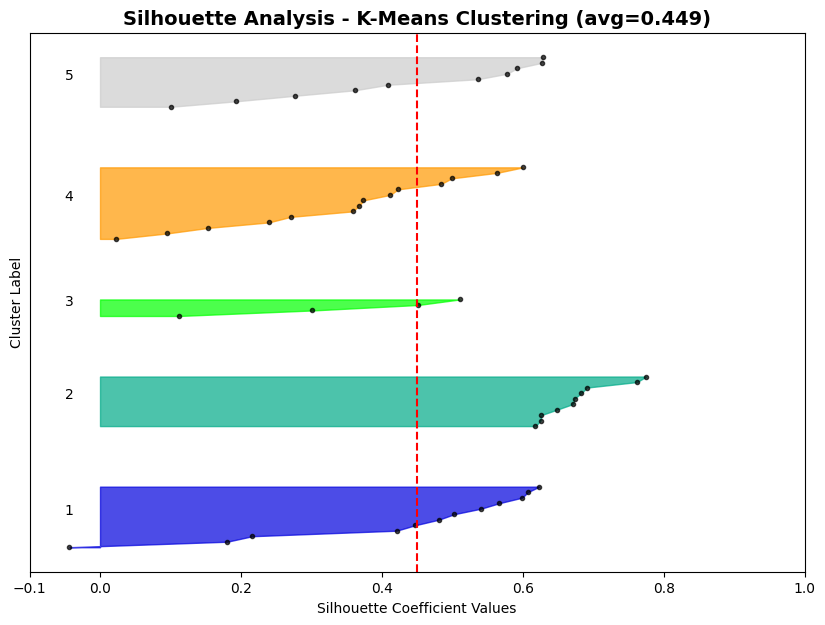


Silhouette Score Comparison:
  Hierarchical: 0.4713
  K-Means:      0.4493


In [27]:
# Create silhouette plot for K-means
plt.figure(figsize=(10, 7))
silhouette_kmeans = silhouette_plot(features, kmeans_labels)
plt.title(
    f"Silhouette Analysis - K-Means Clustering (avg={silhouette_kmeans:.3f})",
    fontsize=14,
    fontweight="bold",
)
plt.show()

print("\nSilhouette Score Comparison:")
print(f"  Hierarchical: {silhouette_hierarchical:.4f}")
print(f"  K-Means:      {silhouette_kmeans:.4f}")

The silhouette plot for K-means shows moderate clustering quality with an average score of approximately 0.45. While some clusters (e.g., Cluster 2) exhibit strong separation with high silhouette values, others contain points near zero, indicating overlap or weak assignments. Compared to hierarchical clustering, K-means appears less consistent across clusters, with greater variability in within-cluster performance.

---

**Problem 3d:** Effect of Scaling

The features in the arrests dataset have very different scales (e.g., UrbanPop is a percentage while Assault can be in the hundreds). Scaling the features before clustering can significantly affect the results.

Use [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to scale the features, then repeat the hierarchical clustering (complete linkage, cut at `t=3.2` for 5 clusters) and K-means clustering (`n_clusters=5`, `random_state=33`).

Store the scaled data in `features_scaled`, the hierarchical labels in `hierarchical_labels_scaled`, and the K-means labels in `kmeans_labels_scaled`.

Compare the silhouette scores with and without scaling.

In [28]:
features_scaled = StandardScaler().fit_transform(features)

arrests_linkage_scaled = linkage(features_scaled, method="complete")
hierarchical_labels_scaled = fcluster(arrests_linkage_scaled, t=3.2, criterion="distance")

kmeans_model_scaled = KMeans(n_clusters=5, random_state=33).fit(features_scaled)
kmeans_labels_scaled = kmeans_model_scaled.labels_ + 1

silhouette_hier_scaled = silhouette_score(features_scaled, hierarchical_labels_scaled)
silhouette_kmeans_scaled = silhouette_score(features_scaled, kmeans_labels_scaled)

print(f"Scaled silhouette score - Hierarchical: {silhouette_hier_scaled:.4f}")
print(f"Scaled silhouette score - K-Means:      {silhouette_kmeans_scaled:.4f}")

Scaled silhouette score - Hierarchical: 0.3174
Scaled silhouette score - K-Means:      0.3152


In [29]:
# Test assertions
assert features_scaled is not None, "features_scaled should be defined"
assert hierarchical_labels_scaled is not None, "hierarchical_labels_scaled should be defined"
assert kmeans_labels_scaled is not None, "kmeans_labels_scaled should be defined"
assert features_scaled.shape == features.shape, "Scaled features should have same shape"
print("All tests passed!")

All tests passed!


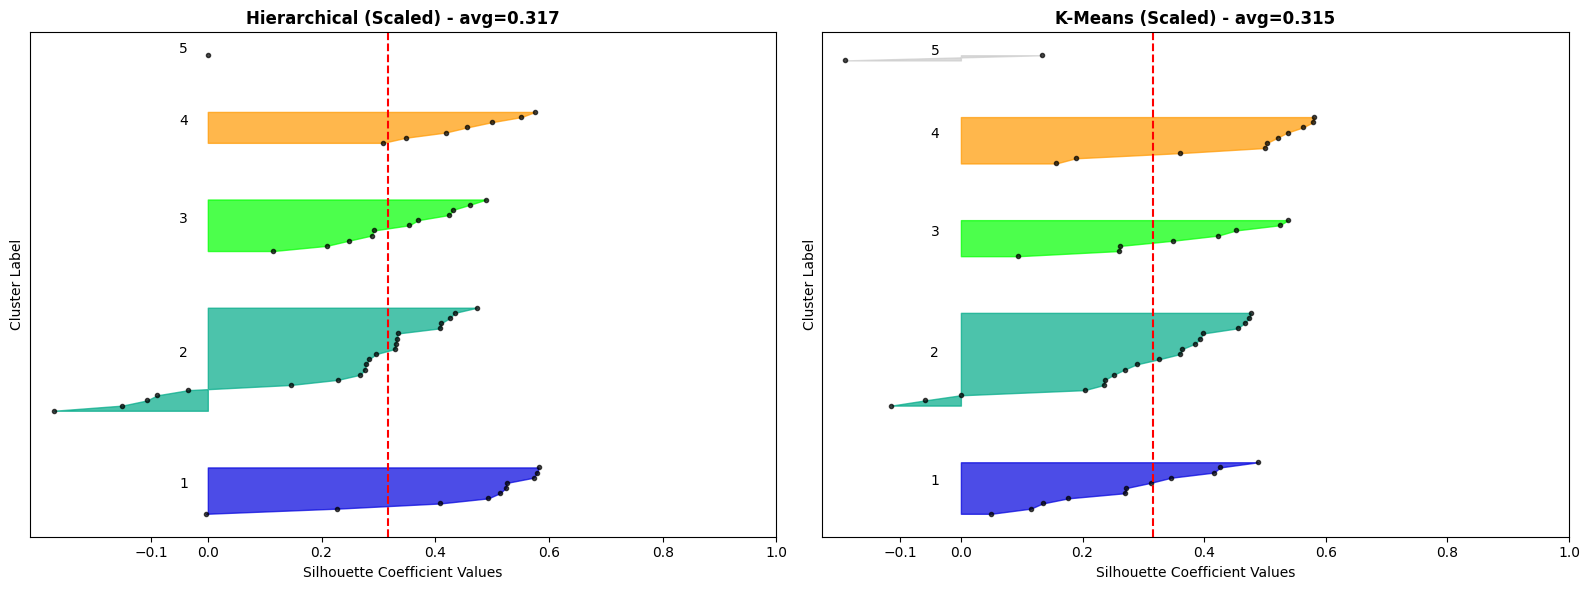


Silhouette Score Comparison:
  Unscaled Hierarchical: 0.4713
  Scaled Hierarchical:   0.3174
  Unscaled K-Means:      0.4493
  Scaled K-Means:        0.3152


In [ ]:
# Silhouette plots for scaled data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# sca method sets the current axes to the specified subplot, allowing us to plot on it
plt.sca(axes[0])
silhouette_hier_scaled = silhouette_plot(features_scaled, hierarchical_labels_scaled)
axes[0].set_title(
    f"Hierarchical (Scaled) - avg={silhouette_hier_scaled:.3f}",
    fontsize=12,
    fontweight="bold",
)

plt.sca(axes[1])
silhouette_kmeans_scaled = silhouette_plot(features_scaled, kmeans_labels_scaled)
axes[1].set_title(
    f"K-Means (Scaled) - avg={silhouette_kmeans_scaled:.3f}",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nSilhouette Score Comparison:")
print(f"  Unscaled Hierarchical: {silhouette_hierarchical:.4f}")
print(f"  Scaled Hierarchical:   {silhouette_hier_scaled:.4f}")
print(f"  Unscaled K-Means:      {silhouette_kmeans:.4f}")
print(f"  Scaled K-Means:        {silhouette_kmeans_scaled:.4f}")

After scaling, silhouette scores decrease substantially for both methods, indicating reduced separation between clusters. This occurs because scaling equalizes feature contributions, which can diminish dominant signals that previously drove cluster separation. While the lower silhouette suggests weaker clustering under the scaled space, it does not necessarily imply worse performance—rather, it reflects a different representation of the data.

---

**Problem 3e:** PCA on Arrests Data

Apply Principal Component Analysis to the (unscaled) arrests data with 3 components using [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

Store the fitted PCA object in a variable called `pca_model`.

Report:
1. The variance explained by each principal component
2. The proportion of variance explained by each component

In [31]:
pca_model = PCA(n_components=3).fit(features)

print("Explained variance:")
for idx, value in enumerate(pca_model.explained_variance_, start=1):
    print(f"  PC{idx}: {value:.4f}")

print("Proportion of variance explained:")
for idx, value in enumerate(pca_model.explained_variance_ratio_, start=1):
    print(f"  PC{idx}: {value:.4f}")

Explained variance:
  PC1: 7011.1149
  PC2: 201.9924
  PC3: 42.1127
Proportion of variance explained:
  PC1: 0.9655
  PC2: 0.0278
  PC3: 0.0058


In [32]:
# Test assertions
assert pca_model is not None, "pca_model should be defined"
assert hasattr(pca_model, "explained_variance_"), "PCA model should be fitted"
assert len(pca_model.explained_variance_) == 3, "Should have 3 components"
print("All tests passed!")

All tests passed!
